In [2]:
import tensorflow as tf

In [3]:
tf.__version__

'1.14.0'

In [4]:
sess = tf.Session(config=tf.ConfigProto(log_device_placement=True))

In [5]:
import os
import sys
import json
import numpy as np
import time
from PIL import Image, ImageDraw

In [6]:
# Set the ROOT_DIR variable to the root directory of the Mask_RCNN git repo
ROOT_DIR = 'C:/Users/Accelerate Guest/Downloads/KAREN/Mask_RCNN'
assert os.path.exists(ROOT_DIR), 'ROOT_DIR does not exist. Did you forget to read the instructions above? ;)'

# Import mrcnn libraries
sys.path.append(ROOT_DIR) 
from mrcnn.config import Config
import mrcnn.utils as utils
from mrcnn import visualize
import mrcnn.model as modellib

Using TensorFlow backend.


In [15]:
# Directory to save logs and trained model
MODEL_DIR = os.path.join(ROOT_DIR, "logs")

# Local path to trained weights file
COCO_MODEL_PATH = os.path.join(ROOT_DIR, "mask_rcnn_v3_0024_.h5")

# Download COCO trained weights from Releases if needed
if not os.path.exists(COCO_MODEL_PATH):
    utils.download_trained_weights(COCO_MODEL_PATH)

In [8]:
class TrainingConfig(Config):
    """Configuration for training on the cigarette butts dataset.
    Derives from the base Config class and overrides values specific
    to the cigarette butts dataset.
    """
    # Give the configuration a recognizable name
    NAME = "v3_from24"

    # Train on 1 GPU and 1 image per GPU. Batch size is 1 (GPUs * images/GPU).
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1

    NUM_CLASSES = 1 + 13  # background + no. of classes

    IMAGE_MIN_DIM = 192
    IMAGE_MAX_DIM = 832

    # You can experiment with this number to see if it improves training
    STEPS_PER_EPOCH = 500

    # This is how often validation is run. If you are using too much hard drive space
    # on saved models (in the MODEL_DIR), try making this value larger.
    VALIDATION_STEPS = 5
    
    # Matterport originally used resnet101, but I downsized to fit it on my graphics card
    BACKBONE = 'resnet101'

    # To be honest, I haven't taken the time to figure out what these do
    RPN_ANCHOR_SCALES = (8, 16, 32, 64, 128)
    TRAIN_ROIS_PER_IMAGE = 32
    MAX_GT_INSTANCES = 50 
    POST_NMS_ROIS_INFERENCE = 500 
    POST_NMS_ROIS_TRAINING = 1000 
    
config = TrainingConfig()
config.display()


Configurations:
BACKBONE                       resnet101
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        100
DETECTION_MIN_CONFIDENCE       0.7
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  832
IMAGE_META_SIZE                26
IMAGE_MIN_DIM                  192
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [832 832   3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE             

In [9]:
class CocoLikeDataset(utils.Dataset):
    """ Generates a COCO-like dataset, i.e. an image dataset annotated in the style of the COCO dataset.
        See http://cocodataset.org/#home for more information.
    """
    def load_data(self, annotation_json, images_dir):
        """ Load the coco-like dataset from json
        Args:
            annotation_json: The path to the coco annotations json file
            images_dir: The directory holding the images referred to by the json file
        """
        # Load json from file
        json_file = open(annotation_json)
        coco_json = json.load(json_file)
        json_file.close()
        
        # Add the class names using the base method from utils.Dataset
        source_name = "coco_like"
        for category in coco_json['categories']:
            class_id = category['id']
            class_name = category['name']
            if class_id < 1:
                print('Error: Class id for "{}" cannot be less than one. (0 is reserved for the background)'.format(class_name))
                return
            
            self.add_class(source_name, class_id, class_name)
        
        # Get all annotations
        annotations = {}
        for annotation in coco_json['annotations']:
            image_id = annotation['image_id']
            if image_id not in annotations:
                annotations[image_id] = []
            annotations[image_id].append(annotation)
        
        # Get all images and add them to the dataset
        seen_images = {}
        for image in coco_json['images']:
            image_id = image['id']
            if image_id in seen_images:
                print("Warning: Skipping duplicate image id: {}".format(image))
            else:
                seen_images[image_id] = image
                try:
                    image_file_name = image['file_name']
                    image_width = image['width']
                    image_height = image['height']
                except KeyError as key:
                    print("Warning: Skipping image (id: {}) with missing key: {}".format(image_id, key))
                
                image_path = os.path.abspath(os.path.join(images_dir, image_file_name))
                image_annotations = annotations[image_id]
                
                # Add the image using the base method from utils.Dataset
                self.add_image(
                    source=source_name,
                    image_id=image_id,
                    path=image_path,
                    width=image_width,
                    height=image_height,
                    annotations=image_annotations
                )
                
    def load_mask(self, image_id):
        """ Load instance masks for the given image.
        MaskRCNN expects masks in the form of a bitmap [height, width, instances].
        Args:
            image_id: The id of the image to load masks for
        Returns:
            masks: A bool array of shape [height, width, instance count] with
                one mask per instance.
            class_ids: a 1D array of class IDs of the instance masks.
        """
        image_info = self.image_info[image_id]
        annotations = image_info['annotations']
        instance_masks = []
        class_ids = []
        
        for annotation in annotations:
            class_id = annotation['category_id']
            mask = Image.new('1', (image_info['width'], image_info['height']))
            mask_draw = ImageDraw.ImageDraw(mask, '1')
            for segmentation in annotation['segmentation']:
                mask_draw.polygon(segmentation, fill=1)
                bool_array = np.array(mask) > 0
                instance_masks.append(bool_array)
                class_ids.append(class_id)

        mask = np.dstack(instance_masks)
        class_ids = np.array(class_ids, dtype=np.int32)
        
        return mask, class_ids

In [10]:
dataset_train = CocoLikeDataset()
dataset_train.load_data('C:/Users/Accelerate Guest/Downloads/KAREN/deepfashion2_train.json', 'C:/Users/Accelerate Guest/Downloads/KAREN/train/image')
dataset_train.prepare()

dataset_val = CocoLikeDataset()
dataset_val.load_data('C:/Users/Accelerate Guest/Downloads/KAREN/deepfashion2_validation.json', 'C:/Users/Accelerate Guest/Downloads/KAREN/validation/image')
dataset_val.prepare()

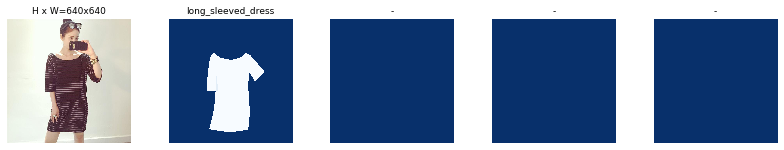

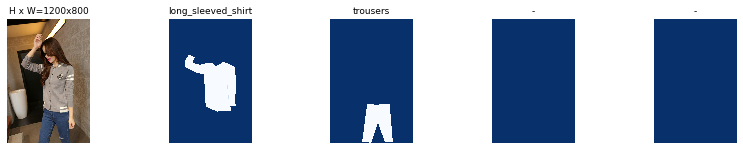

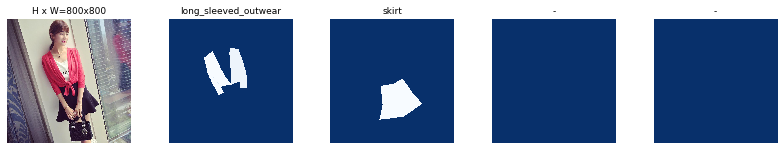

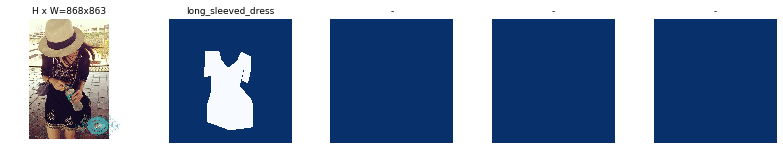

In [11]:
dataset = dataset_train
image_ids = np.random.choice(dataset.image_ids, 4)
for image_id in image_ids:
    image = dataset.load_image(image_id)
    mask, class_ids = dataset.load_mask(image_id)
    visualize.display_top_masks(image, mask, class_ids, dataset.class_names)

In [12]:
model = modellib.MaskRCNN(mode="training", config=config, model_dir=MODEL_DIR)







Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Instructions for updating:
box_ind is deprecated, use box_indices instead


In [16]:
# Which weights to start with?
init_with = "own"  # imagenet, coco, or last

if init_with == "imagenet":
    model.load_weights(model.get_imagenet_weights(), by_name=True)
elif init_with == "coco":
    # Load weights trained on MS COCO, but skip layers that
    # are different due to the different number of classes
    # See README for instructions to download the COCO weights
    model.load_weights(COCO_MODEL_PATH, by_name=True,
                       exclude=["mrcnn_class_logits", "mrcnn_bbox_fc", 
                                "mrcnn_bbox", "mrcnn_mask"])
elif init_with == "last":
    # Load the last model you trained and continue training
    model.load_weights(model.find_last(), by_name=True)
    
elif init_with == "own":
    model.load_weights(COCO_MODEL_PATH, by_name=True)

In [17]:
start_train = time.time()

model.train(dataset_train, dataset_val, 
            learning_rate=config.LEARNING_RATE, 
            epochs=10, 
            layers='heads')

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Training took {minutes} minutes')


Starting at epoch 0. LR=0.001

Checkpoint Path: C:/Users/Accelerate Guest/Downloads/KAREN/Mask_RCNN\logs\v3_from2420191016T1142\mask_rcnn_v3_from24_{epoch:04d}.h5
Selecting layers to train
fpn_c5p5               (Conv2D)
fpn_c4p4               (Conv2D)
fpn_c3p3               (Conv2D)
fpn_c2p2               (Conv2D)
fpn_p5                 (Conv2D)
fpn_p2                 (Conv2D)
fpn_p3                 (Conv2D)
fpn_p4                 (Conv2D)
In model:  rpn_model
    rpn_conv_shared        (Conv2D)
    rpn_class_raw          (Conv2D)
    rpn_bbox_pred          (Conv2D)
mrcnn_mask_conv1       (TimeDistributed)
mrcnn_mask_bn1         (TimeDistributed)
mrcnn_mask_conv2       (TimeDistributed)
mrcnn_mask_bn2         (TimeDistributed)
mrcnn_class_conv1      (TimeDistributed)
mrcnn_class_bn1        (TimeDistributed)
mrcnn_mask_conv3       (TimeDistributed)
mrcnn_mask_bn3         (TimeDistributed)
mrcnn_class_conv2      (TimeDistributed)
mrcnn_class_bn2        (TimeDistributed)
mrcnn_mask_conv

C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "




Epoch 1/10
500/500 [==============================] - 5625s 11s/step - loss: 2.1621 - rpn_class_loss: 0.0045 - rpn_bbox_loss: 1.1287 - mrcnn_class_loss: 0.5916 - mrcnn_bbox_loss: 0.2049 - mrcnn_mask_loss: 0.2326 - val_loss: 1.1359 - val_rpn_class_loss: 0.0022 - val_rpn_bbox_loss: 0.5165 - val_mrcnn_class_loss: 0.3333 - val_mrcnn_bbox_loss: 0.1079 - val_mrcnn_mask_loss: 0.1760
Epoch 2/10
500/500 [==============================] - 5585s 11s/step - loss: 1.9853 - rpn_class_loss: 0.0042 - rpn_bbox_loss: 1.0656 - mrcnn_class_loss: 0.5121 - mrcnn_bbox_loss: 0.1864 - mrcnn_mask_loss: 0.2170 - val_loss: 2.0445 - val_rpn_class_loss: 0.0064 - val_rpn_bbox_loss: 0.9599 - val_mrcnn_class_loss: 0.5603 - val_mrcnn_bbox_loss: 0.2793 - val_mrcnn_mask_loss: 0.2386
Epoch 3/10
500/500 [==============================] - 5595s 11s/step - loss: 1.9393 - rpn_class_loss: 0.0046 - rpn_bbox_loss: 1.0420 - mrcnn_class_loss: 0.4852 - mrcnn_bbox_loss: 0.1848 - mrcnn_mask_loss: 0.2227 - val_loss: 2.0166 - val_rpn

In [18]:
start_train = time.time()

model.train(dataset_train, dataset_val, 
            learning_rate=config.LEARNING_RATE / 10,
            epochs=20, 
            layers="all")

end_train = time.time()
minutes = round((end_train - start_train) / 60, 2)
print(f'Training took {minutes} minutes')


Starting at epoch 10. LR=0.0001

Checkpoint Path: C:/Users/Accelerate Guest/Downloads/KAREN/Mask_RCNN\logs\v3_from2420191016T1142\mask_rcnn_v3_from24_{epoch:04d}.h5
Selecting layers to train
conv1                  (Conv2D)
bn_conv1               (BatchNorm)
res2a_branch2a         (Conv2D)
bn2a_branch2a          (BatchNorm)
res2a_branch2b         (Conv2D)
bn2a_branch2b          (BatchNorm)
res2a_branch2c         (Conv2D)
res2a_branch1          (Conv2D)
bn2a_branch2c          (BatchNorm)
bn2a_branch1           (BatchNorm)
res2b_branch2a         (Conv2D)
bn2b_branch2a          (BatchNorm)
res2b_branch2b         (Conv2D)
bn2b_branch2b          (BatchNorm)
res2b_branch2c         (Conv2D)
bn2b_branch2c          (BatchNorm)
res2c_branch2a         (Conv2D)
bn2c_branch2a          (BatchNorm)
res2c_branch2b         (Conv2D)
bn2c_branch2b          (BatchNorm)
res2c_branch2c         (Conv2D)
bn2c_branch2c          (BatchNorm)
res3a_branch2a         (Conv2D)
bn3a_branch2a          (BatchNorm)
res3

C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "
C:\Users\Accelerate Guest\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\ops\gradients_util.py:93: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Epoch 11/20
500/500 [==============================] - 14349s 29s/step - loss: 1.8574 - rpn_class_loss: 0.0041 - rpn_bbox_loss: 1.0238 - mrcnn_class_loss: 0.4559 - mrcnn_bbox_loss: 0.1544 - mrcnn_mask_loss: 0.2192 - val_loss: 2.1364 - val_rpn_class_loss: 0.0045 - val_rpn_bbox_loss: 1.1811 - val_mrcnn_class_loss: 0.4982 - val_mrcnn_bbox_loss: 0.1546 - val_mrcnn_mask_loss: 0.2981
Epoch 12/20
500/500 [==============================] - 14450s 29s/step - loss: 1.7194 - rpn_class_loss: 0.0039 - rpn_bbox_loss: 0.9258 - mrcnn_class_loss: 0.4334 - mrcnn_bbox_loss: 0.1429 - mrcnn_mask_loss: 0.2133 - val_loss: 2.5352 - val_rpn_class_loss: 0.0018 - val_rpn_bbox_loss: 1.6163 - val_mrcnn_class_loss: 0.5436 - val_mrcnn_bbox_loss: 0.1407 - val_mrcnn_mask_loss: 0.2327
Epoch 13/20
500/500 [==============================] - 14199s 28s/step - loss: 1.6416 - rpn_class_loss: 0.0036 - rpn_bbox_loss: 0.8577 - mrcnn_class_loss: 0.4400 - mrcnn_bbox_loss: 0.1322 - mrcnn_mask_loss: 0.2082 - val_loss: 1.9488 - val

In [19]:
class InferenceConfig(TrainingConfig):
    GPU_COUNT = 1
    IMAGES_PER_GPU = 1
    IMAGE_MIN_DIM = 192
    IMAGE_MAX_DIM = 832
    DETECTION_MIN_CONFIDENCE = 0.85
    
inference_config = InferenceConfig()
inference_config.display()


Configurations:
BACKBONE                       resnet101
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     1
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        100
DETECTION_MIN_CONFIDENCE       0.85
DETECTION_NMS_THRESHOLD        0.3
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 1
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  832
IMAGE_META_SIZE                26
IMAGE_MIN_DIM                  192
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [832 832   3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE            

In [20]:
# Recreate the model in inference mode
model = modellib.MaskRCNN(mode="inference", config=inference_config, model_dir=MODEL_DIR)


Instructions for updating:
Use `tf.cast` instead.


In [21]:
model_path = model.find_last()

# Load trained weights (fill in path to trained weights here)
assert model_path != "", "Provide path to trained weights"
print("Loading weights from ", model_path)
model.load_weights(model_path, by_name=True)

Loading weights from  C:/Users/Accelerate Guest/Downloads/KAREN/Mask_RCNN\logs\v3_from2420191016T1142\mask_rcnn_v3_from24_0020.h5
Re-starting from epoch 20


Processing 1 images
image                    shape: (400, 235, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


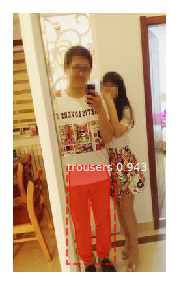

Processing 1 images
image                    shape: (400, 235, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


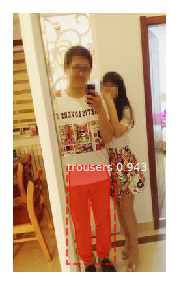

Processing 1 images
image                    shape: (624, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



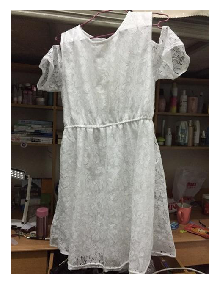

Processing 1 images
image                    shape: (263, 468, 3)         min:    1.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



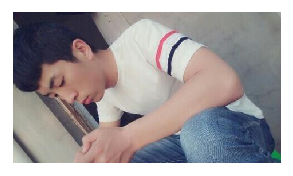

Processing 1 images
image                    shape: (1064, 588, 3)        min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max: 1064.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


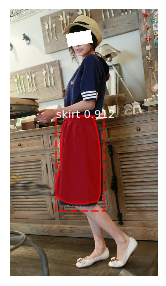

Processing 1 images
image                    shape: (640, 640, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



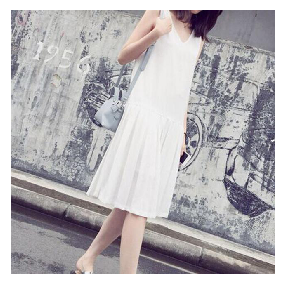

Processing 1 images
image                    shape: (784, 640, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


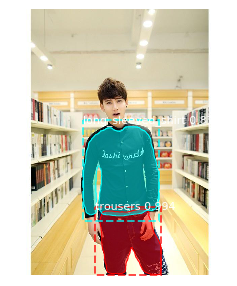

Processing 1 images
image                    shape: (930, 735, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  930.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



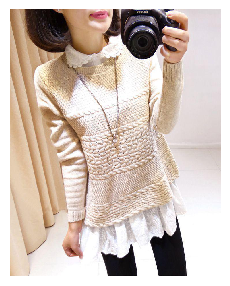

Processing 1 images
image                    shape: (866, 750, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  866.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


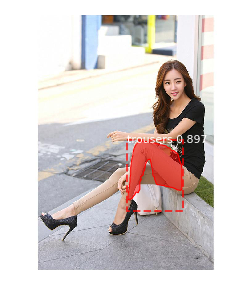

Processing 1 images
image                    shape: (640, 640, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



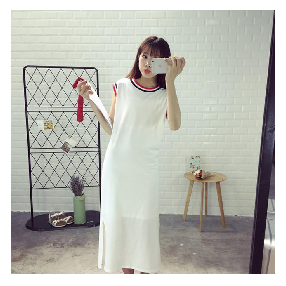

In [22]:
import skimage
real_test_dir = 'C:/Users/Accelerate Guest/Downloads/KAREN/test/test10'
image_paths = []
for filename in os.listdir(real_test_dir):
    if os.path.splitext(filename)[1].lower() in ['.png', '.jpg', '.jpeg']:
        image_paths.append(os.path.join(real_test_dir, filename))

for image_path in image_paths:
    img = skimage.io.imread(image_path)
    img_arr = np.array(img)
    results = model.detect([img_arr], verbose=1)
    r = results[0]
    visualize.display_instances(img, r['rois'], r['masks'], r['class_ids'], 
                                dataset_val.class_names, r['scores'], figsize=(5,5))

Processing 1 images
image                    shape: (624, 468, 3)         min:    0.00000  max:  250.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  145.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



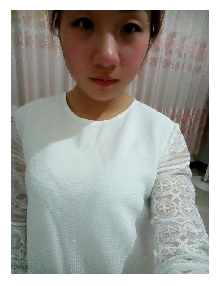

Processing 1 images
image                    shape: (627, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


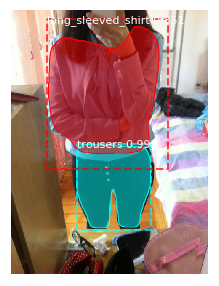

Processing 1 images
image                    shape: (624, 468, 3)         min:    0.00000  max:  234.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  130.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



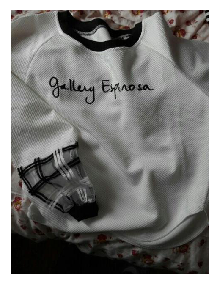

Processing 1 images
image                    shape: (625, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


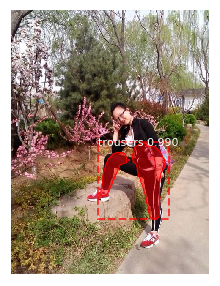

Processing 1 images
image                    shape: (468, 351, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



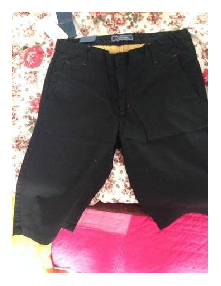

Processing 1 images
image                    shape: (631, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



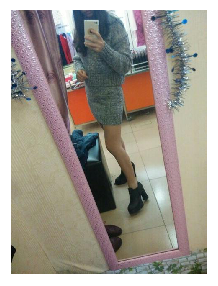

Processing 1 images
image                    shape: (624, 468, 3)         min:    0.00000  max:  235.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  130.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


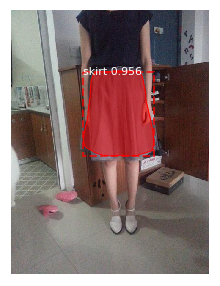

Processing 1 images
image                    shape: (624, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



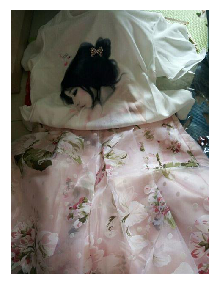

Processing 1 images
image                    shape: (702, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


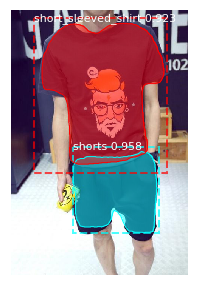

Processing 1 images
image                    shape: (808, 644, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


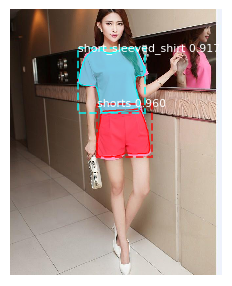

In [23]:
real_test_dir = 'C:/Users/Accelerate Guest/Downloads/KAREN/test/test10_1'
image_paths = []
for filename in os.listdir(real_test_dir):
    if os.path.splitext(filename)[1].lower() in ['.png', '.jpg', '.jpeg']:
        image_paths.append(os.path.join(real_test_dir, filename))

for image_path in image_paths:
    img = skimage.io.imread(image_path)
    img_arr = np.array(img)
    results = model.detect([img_arr], verbose=1)
    r = results[0]
    visualize.display_instances(img, r['rois'], r['masks'], r['class_ids'], 
                                dataset_val.class_names, r['scores'], figsize=(5,5))

Processing 1 images
image                    shape: (600, 450, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


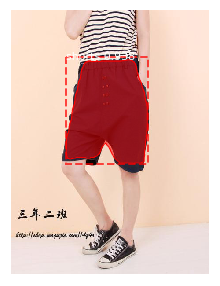

Processing 1 images
image                    shape: (938, 750, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  938.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


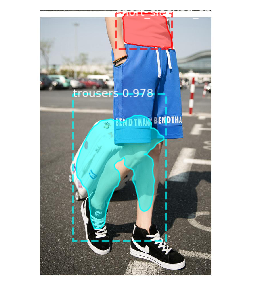

Processing 1 images
image                    shape: (1320, 880, 3)        min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max: 1320.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



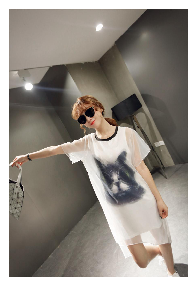

Processing 1 images
image                    shape: (936, 750, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  936.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


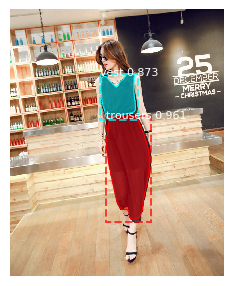

Processing 1 images
image                    shape: (975, 640, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  975.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


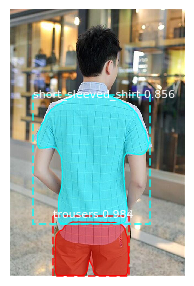

Processing 1 images
image                    shape: (970, 750, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  970.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



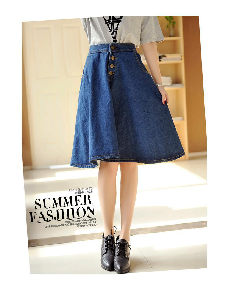

Processing 1 images
image                    shape: (646, 670, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


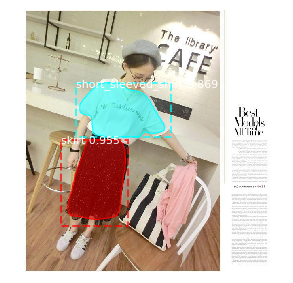

Processing 1 images
image                    shape: (1027, 700, 3)        min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max: 1027.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


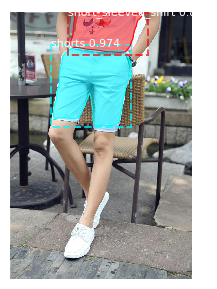

Processing 1 images
image                    shape: (702, 468, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max:  832.00000  int32
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32

*** No instances to display *** 



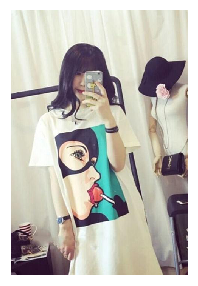

Processing 1 images
image                    shape: (1248, 750, 3)        min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 832, 832, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 26)               min:    0.00000  max: 1248.00000  float64
anchors                  shape: (1, 172887, 4)        min:   -0.10892  max:    1.03190  float32


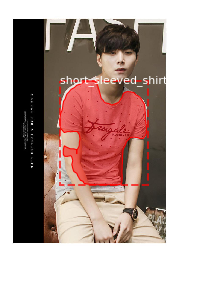

In [24]:
real_test_dir = 'C:/Users/Accelerate Guest/Downloads/KAREN/test/test10_2'
image_paths = []
for filename in os.listdir(real_test_dir):
    if os.path.splitext(filename)[1].lower() in ['.png', '.jpg', '.jpeg']:
        image_paths.append(os.path.join(real_test_dir, filename))

for image_path in image_paths:
    img = skimage.io.imread(image_path)
    img_arr = np.array(img)
    results = model.detect([img_arr], verbose=1)
    r = results[0]
    visualize.display_instances(img, r['rois'], r['masks'], r['class_ids'], 
                                dataset_val.class_names, r['scores'], figsize=(5,5))

In [25]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 10)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 10 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 10 images:  0.33333333432674406
Time cost: 1.49 minutes


In [26]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 50)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 50 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 50 images:  0.2983333343267441
Time cost: 7.25 minutes


In [27]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 100)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 100 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 100 images:  0.32869047691424685
Time cost: 14.69 minutes


In [28]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 200)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 200 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 200 images:  0.2477777790029844
Time cost: 29.35 minutes


In [29]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 300)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 300 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 300 images:  0.22638888986574277
Time cost: 40.92 minutes


In [30]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 500)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 500 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 500 images:  0.26050681933760644
Time cost: 67.0 minutes


In [31]:
start_train = time.time()

image_ids = np.random.choice(dataset_val.image_ids, 1000)
APs = []
for image_id in image_ids:
    # Load image and ground truth data
    image, image_meta, gt_class_id, gt_bbox, gt_mask =\
        modellib.load_image_gt(dataset_val, inference_config,
                               image_id, use_mini_mask=False)
    molded_images = np.expand_dims(modellib.mold_image(image, inference_config), 0)
    # Run object detection
    results = model.detect([image], verbose=0)
    r = results[0]
    # Compute AP
    AP, precisions, recalls, overlaps =\
        utils.compute_ap(gt_bbox, gt_class_id, gt_mask,
                         r["rois"], r["class_ids"], r["scores"], r['masks'])
    APs.append(AP)
    
print("Mean of mAP for random 1000 images: ", np.mean(APs))

end_train = time.time()

minutes = round((end_train - start_train) / 60, 2)
print(f'Time cost: {minutes} minutes')

Mean of mAP for random 1000 images:  0.22759583407640457
Time cost: 136.8 minutes
